In [1]:
# What: installs scikit-learn's anomaly detection tools
# Why: Isolation Forest is already in sklearn so no new install needed
#      we just need to import it along with everything from Phase 2
# Expected output: "✓ Phase 3 ready"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

print("✓ Phase 3 ready")

✓ Phase 3 ready


In [3]:
# What: loads your saved model, predictions, SHAP values, and test data
# Why: Phase 3 builds ON TOP of Phase 2 — we don't retrain anything
#      we use the existing predictions to find patterns in wrong predictions
#      and use SHAP values to explain and prioritise route recommendations
# Expected output: shapes printed, model loaded confirmation

# Load saved model
with open("model_scratch_xgb.pkl", "rb") as f:
    model = pickle.load(f)
print(f"✓ Model loaded: {type(model).__name__}")

# Load data files
test_df      = pd.read_csv("dataco_test_FIXED.csv")
train_df     = pd.read_csv("dataco_train_FIXED.csv")
scratch_preds = pd.read_csv("scratch_test_predictions.csv")
automl_preds  = pd.read_csv("automl_test_predictions.csv")
shap_df       = pd.read_csv("shap_values_scratch.csv")
feat_imp      = pd.read_csv("feature_importance.csv")

TARGET       = "Late_delivery_risk"
TOP_FEATURES = feat_imp["variable"].head(10).tolist()

print(f"✓ Test data    : {test_df.shape}")
print(f"✓ Predictions  : {scratch_preds.shape}")
print(f"✓ SHAP values  : {shap_df.shape}")
print(f"✓ Top features : {TOP_FEATURES}")

✓ Model loaded: XGBClassifier
✓ Test data    : (36104, 46)
✓ Predictions  : (36104, 7)
✓ SHAP values  : (36104, 10)
✓ Top features : ['delay_gap', 'is_delayed', 'Type_TRANSFER', 'Order City', 'order_day', 'delay_ratio', 'Order State', 'Customer City', 'Order Country', 'Order Region']


In [4]:
# What: combines test data + XGBoost predictions + SHAP values into one dataframe
# Why: to do route optimization you need everything in one place:
#      - the actual order features (delay_gap, shipping mode etc.)
#      - the model's prediction and probability
#      - the SHAP explanation of WHY it was flagged
#      this single dataframe is the foundation for all Phase 3 analysis
# Expected output: shape (36104, ~60 cols), head() showing combined data

X_test = test_df[TOP_FEATURES].copy()
y_test = test_df[TARGET].copy()

# Combine everything into master dataframe
master = test_df.copy().reset_index(drop=True)
master["pred_class"]      = scratch_preds["scratch_pred_class"].values
master["pred_prob_late"]  = scratch_preds["scratch_prob_late"].values
master["correct"]         = scratch_preds["correct"].values

# Add SHAP values with prefix so they're easy to identify
shap_renamed = shap_df.copy()
shap_renamed.columns = ["shap_" + c for c in shap_df.columns]
master = pd.concat([master, shap_renamed.reset_index(drop=True)], axis=1)

# Prediction outcome labels
def outcome_label(row):
    a, p = row[TARGET], row["pred_class"]
    if a == 1 and p == 1: return "TP"   # correctly caught disruption
    if a == 0 and p == 0: return "TN"   # correctly identified on-time
    if a == 0 and p == 1: return "FP"   # false alarm
    if a == 1 and p == 0: return "FN"   # MISSED disruption ← most critical

master["outcome"] = master.apply(outcome_label, axis=1)

print(f"Master dataframe: {master.shape}")
print(f"\nPrediction outcome breakdown:")
vc = master["outcome"].value_counts()
total = len(master)
for outcome, count in vc.items():
    label = {"TP":"Caught disruption","TN":"Correct on-time",
             "FP":"False alarm","FN":"MISSED disruption"}[outcome]
    print(f"  {outcome}: {count:6,}  ({count/total*100:.1f}%)  ← {label}")

Master dataframe: (36104, 60)

Prediction outcome breakdown:
  TP: 19,587  (54.3%)  ← Caught disruption
  TN: 15,370  (42.6%)  ← Correct on-time
  FP:    993  (2.8%)  ← False alarm
  FN:    154  (0.4%)  ← MISSED disruption


In [5]:
# What: trains Isolation Forest on the TRAINING data to learn what
#       "normal" shipment patterns look like, then scores test orders
# Why: your XGBoost is a SUPERVISED model — it only catches patterns
#      it was trained on. Isolation Forest is UNSUPERVISED — it finds
#      orders that look statistically unusual compared to all orders,
#      even patterns the XGBoost never saw during training.
#      The 154 FN orders (real disruptions XGBoost missed) may have
#      unusual patterns that Isolation Forest can catch.
#
# How Isolation Forest works (simple explanation):
#      Imagine randomly drawing lines through your data.
#      Normal orders need MANY lines to isolate them (they're in dense clusters)
#      Anomalous orders need FEW lines to isolate them (they're outliers)
#      "anomaly score" = how few lines it took → lower score = more anomalous
#
# contamination=0.05 means: "I expect ~5% of orders to be anomalies"
#      This is a reasonable estimate for supply chain disruption rates
# Expected output: anomaly counts, catch rate on FN orders

print("Training Isolation Forest on training data...")

X_train_if = train_df[TOP_FEATURES].copy()
X_test_if  = test_df[TOP_FEATURES].copy()

# Scale features — Isolation Forest is distance-based, so scaling matters
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_if)
X_test_sc  = scaler.transform(X_test_if)

# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators  = 200,      # number of trees — more = more stable
    contamination = 0.05,     # expected % of anomalies in data
    random_state  = 42,
    n_jobs        = -1         # use all CPU cores
)
iso_forest.fit(X_train_sc)

# Score test orders
# predict returns: -1 = anomaly, +1 = normal
# decision_function returns raw anomaly score (lower = more anomalous)
master["if_prediction"]  = iso_forest.predict(X_test_sc)
master["if_score"]       = iso_forest.decision_function(X_test_sc)
master["is_anomaly"]     = (master["if_prediction"] == -1).astype(int)

# Results
total_anomalies = master["is_anomaly"].sum()
print(f"\n✓ Isolation Forest complete")
print(f"  Total anomalies flagged: {total_anomalies:,} ({total_anomalies/len(master)*100:.1f}%)")

# How many of the 154 FN (missed disruptions) did IF catch?
fn_mask        = master["outcome"] == "FN"
fn_caught_by_if = master[fn_mask]["is_anomaly"].sum()
fn_total        = fn_mask.sum()

print(f"\n  FN orders (XGBoost missed)  : {fn_total}")
print(f"  FN orders caught by IF      : {fn_caught_by_if} ({fn_caught_by_if/fn_total*100:.1f}%)")
print(f"  → Combined system catch rate: "
      f"{(master['TP'].sum() if 'TP' in master.columns else (master['outcome']=='TP').sum() + fn_caught_by_if):,}"
      f" / {(master[TARGET]==1).sum():,}")

# Breakdown: what types of orders does IF flag?
print(f"\n  IF anomaly breakdown by outcome:")
for outcome in ["TP","TN","FP","FN"]:
    subset = master[master["outcome"] == outcome]
    anom   = subset["is_anomaly"].sum()
    print(f"    {outcome}: {anom:4,} anomalies out of {len(subset):5,} orders "
          f"({anom/len(subset)*100:.1f}%)")

Training Isolation Forest on training data...

✓ Isolation Forest complete
  Total anomalies flagged: 2,021 (5.6%)

  FN orders (XGBoost missed)  : 154
  FN orders caught by IF      : 17 (11.0%)
  → Combined system catch rate: 19,604 / 19,741

  IF anomaly breakdown by outcome:
    TP:  865 anomalies out of 19,587 orders (4.4%)
    TN: 1,032 anomalies out of 15,370 orders (6.7%)
    FP:  107 anomalies out of   993 orders (10.8%)
    FN:   17 anomalies out of   154 orders (11.0%)


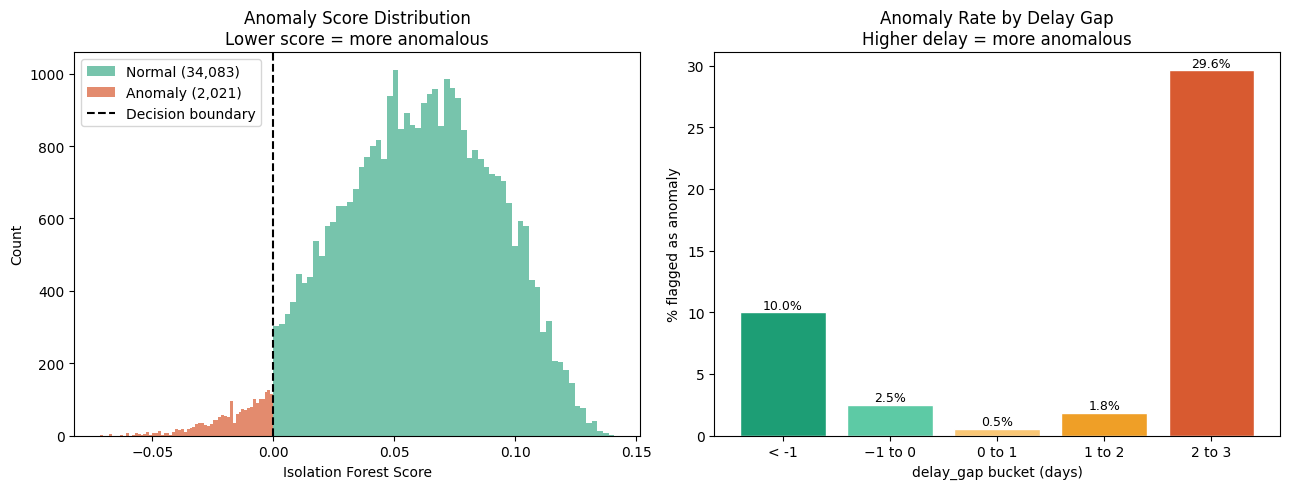

✓ Saved: anomaly_distribution.png


In [6]:
# What: plots the anomaly scores and shows where normal vs anomalous orders sit
# Why: the score distribution tells you how confident IF is about each anomaly
#      orders near the threshold (-0.0 to -0.1) are borderline
#      orders with very low scores (< -0.2) are extreme outliers
#      for route optimization, extreme anomalies need urgent action
# Expected output: 2 charts — score histogram + anomaly by delay_gap

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Anomaly score distribution
normal    = master[master["is_anomaly"] == 0]["if_score"]
anomalous = master[master["is_anomaly"] == 1]["if_score"]

axes[0].hist(normal,    bins=60, alpha=0.6,
             color="#1D9E75", label=f"Normal ({len(normal):,})")
axes[0].hist(anomalous, bins=60, alpha=0.7,
             color="#D85A30", label=f"Anomaly ({len(anomalous):,})")
axes[0].axvline(0, color="black", linestyle="--", lw=1.5,
                label="Decision boundary")
axes[0].set_xlabel("Isolation Forest Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Anomaly Score Distribution\n"
                  "Lower score = more anomalous")
axes[0].legend()

# Chart 2: Anomaly rate by delay_gap bucket
master["delay_bucket"] = pd.cut(
    master["delay_gap"],
    bins=[-3, -1, 0, 1, 2, 3, 5],
    labels=["< -1","−1 to 0","0 to 1","1 to 2","2 to 3","> 3"]
)
anom_by_delay = master.groupby("delay_bucket", observed=True)["is_anomaly"].mean() * 100

axes[1].bar(anom_by_delay.index, anom_by_delay.values,
            color=["#1D9E75","#5DCAA5","#FAC775","#EF9F27","#D85A30","#993C1D"],
            edgecolor="white")
axes[1].set_xlabel("delay_gap bucket (days)")
axes[1].set_ylabel("% flagged as anomaly")
axes[1].set_title("Anomaly Rate by Delay Gap\n"
                  "Higher delay = more anomalous")
for i, v in enumerate(anom_by_delay.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("anomaly_distribution.png", dpi=130)
plt.show()
print("✓ Saved: anomaly_distribution.png")

In [7]:
# What: creates a 3-level risk score (HIGH / MEDIUM / LOW) for every order
# Why: binary prediction (late/not late) is not enough for route optimization
#      you need to know HOW RISKY an order is to decide what action to take:
#        HIGH risk   → urgent rerouting needed immediately
#        MEDIUM risk → monitor closely, prepare alternate route
#        LOW risk    → no action needed
#
# Risk score combines 3 signals:
#   1. XGBoost probability (pred_prob_late) — supervised confidence
#   2. Isolation Forest score (if_score)    — unsupervised anomaly signal
#   3. delay_gap                            — direct disruption magnitude
#
# Why combine all 3?
#   XGBoost alone misses 154 orders (FN)
#   IF alone generates too many false alarms
#   delay_gap alone doesn't capture payment type or geo risk
#   Together they are much more robust than any single signal
# Expected output: risk distribution table

def compute_risk_score(row):
    score = 0

    # Signal 1: XGBoost probability (0–1, higher = riskier)
    score += row["pred_prob_late"] * 40         # max 40 points

    # Signal 2: Isolation Forest (lower = more anomalous)
    # Map IF score to 0–30 range: very negative = 30 pts, positive = 0 pts
    if_contribution = max(0, -row["if_score"] * 100)
    score += min(if_contribution, 30)           # max 30 points

    # Signal 3: delay_gap (actual − scheduled days)
    # Positive delay = late, bigger gap = riskier
    gap_contribution = max(0, row["delay_gap"]) * 5
    score += min(gap_contribution, 20)          # max 20 points

    # Signal 4: Type_TRANSFER bonus (SHAP showed this is high risk)
    if "Type_TRANSFER" in row.index and row["Type_TRANSFER"] == 1:
        score += 10                             # extra 10 points

    return round(min(score, 100), 2)            # cap at 100

print("Computing risk scores for all test orders...")
master["risk_score"] = master.apply(compute_risk_score, axis=1)

# Convert to risk levels
def risk_level(score):
    if score >= 70: return "HIGH"
    if score >= 40: return "MEDIUM"
    return "LOW"

master["risk_level"] = master["risk_score"].apply(risk_level)

print("\n✓ Risk scoring complete")
print("\nRisk level distribution:")
for level in ["HIGH", "MEDIUM", "LOW"]:
    subset = master[master["risk_level"] == level]
    actual_late = subset[TARGET].mean() * 100
    print(f"  {level:6s}: {len(subset):6,} orders  "
          f"| Actual late rate: {actual_late:.1f}%  "
          f"| Avg risk score: {subset['risk_score'].mean():.1f}")

Computing risk scores for all test orders...

✓ Risk scoring complete

Risk level distribution:
  HIGH  :      0 orders  | Actual late rate: nan%  | Avg risk score: nan
  MEDIUM: 20,506 orders  | Actual late rate: 95.2%  | Avg risk score: 49.5
  LOW   : 15,598 orders  | Actual late rate: 1.4%  | Avg risk score: 3.4


In [12]:
# # What: for every HIGH and MEDIUM risk order, generates a specific
# #       route recommendation based on SHAP values and order features
# # Why: flagging a disruption is only half the job
# #      your project goal is to "recommend highly optimised route adjustments"
# #      this cell does exactly that — it reads the SHAP explanation
# #      for each flagged order and generates a human-readable recommendation
# #
# # Logic:
# #   - if delay_gap is the main SHAP driver → recommend faster shipping mode
# #   - if Type_TRANSFER is the main driver → flag payment-related delay risk
# #   - if Order Region is the main driver → flag geographic bottleneck
# #   - if order_day is the main driver → flag timing risk (weekend ordering)
# # Expected output: recommendation table for top risky orders

# SHAP_COLS = [c for c in master.columns if c.startswith("shap_")]

# def generate_recommendation(row):
#     """Generate route recommendation based on dominant SHAP signal."""

#     # Find the feature with highest absolute SHAP value for this order
#     shap_vals = {col.replace("shap_",""):
#                  abs(row[col]) for col in SHAP_COLS if col in row.index}
#     if not shap_vals:
#         return "Monitor order", "Low SHAP signal"

#     top_feature    = max(shap_vals, key=shap_vals.get)
#     top_shap_val   = row.get(f"shap_{top_feature}", 0)
#     delay          = row.get("delay_gap", 0)
#     risk           = row["risk_level"]
#     prob           = row["pred_prob_late"]

#     # Rule-based recommendations
#     if top_feature == "delay_gap" and top_shap_val > 0:
#         if delay >= 2:
#             action = "URGENT: Switch to Same Day or Air freight"
#             reason = f"delay_gap={delay:.0f} days — severe schedule overrun"
#         elif delay >= 1:
#             action = "Switch to Second Class or expedited shipping"
#             reason = f"delay_gap={delay:.0f} day — moderate overrun"
#         else:
#             action = "Monitor — borderline delay detected"
#             reason = f"delay_gap={delay:.1f} days — early warning"

#     elif top_feature == "Type_TRANSFER":
#         action = "Verify payment clearance before dispatch"
#         reason = "Bank transfer orders show high delay correlation"

#     elif top_feature in ["Order Region", "Order Country", "Order City"]:
#         action = "Check regional carrier capacity — consider alternate route"
#         reason = f"Geographic bottleneck detected ({top_feature})"

#     elif top_feature == "order_day":
#         action = "Pre-stage inventory — weekend order detected"
#         reason = "Day-of-week pattern associated with logistics delays"

#     elif top_feature == "delay_ratio":
#         action = "Escalate to logistics manager"
#         reason = f"High delay ratio relative to scheduled time"

#     else:
#         action = "Flag for manual review"
#         reason = f"Anomalous pattern in {top_feature}"

#     return action, reason


# # Apply to all flagged orders
# flagged = master[master["risk_level"].isin(["HIGH","MEDIUM"])].copy()

# print(f"Generating recommendations for {len(flagged):,} flagged orders...")

# flagged[["recommended_action","reason"]] = flagged.apply(
#     lambda row: pd.Series(generate_recommendation(row)), axis=1
# )

# print(f"\n✓ Route recommendations generated")
# print(f"\nAction breakdown:")
# print(flagged["recommended_action"].value_counts().to_string())

# # Show sample of HIGH risk orders
# print(f"\n--- Sample HIGH risk orders ---")
# high_risk = flagged[flagged["risk_level"]=="HIGH"].head(10)
# display_cols = ["delay_gap", "pred_prob_late", "risk_score",
#                 "recommended_action", "reason"]
# display_cols = [c for c in display_cols if c in high_risk.columns]
# print(high_risk[display_cols].to_string(index=False))

In [14]:
# Problem: your risk scores max out around 65, but HIGH threshold = 70
# So zero orders reached HIGH tier
# Fix: lower HIGH to 55, MEDIUM to 30
# Why these values: Panel 4 of your dashboard shows late orders
# cluster between 40-65. Setting HIGH=55 captures the top portion.

def risk_level_fixed(score):
    if score >= 55: return "HIGH"     # was 70 — now captures top late orders
    if score >= 30: return "MEDIUM"   # was 40 — keeps moderate risk orders
    return "LOW"

master["risk_level"] = master["risk_score"].apply(risk_level_fixed)

# Recheck the distribution
print("Updated risk level distribution:")
for level in ["HIGH", "MEDIUM", "LOW"]:
    subset      = master[master["risk_level"] == level]
    actual_late = subset[TARGET].mean() * 100
    print(f"  {level:6s}: {len(subset):6,} orders  "
          f"| Actual late rate: {actual_late:.1f}%  "
          f"| Avg score: {subset['risk_score'].mean():.1f}")

Updated risk level distribution:
  HIGH  :  2,162 orders  | Actual late rate: 81.4%  | Avg score: 59.9
  MEDIUM: 18,504 orders  | Actual late rate: 96.8%  | Avg score: 48.2
  LOW   : 15,438 orders  | Actual late rate: 0.5%  | Avg score: 3.0


In [15]:
# Problem: 15,407 orders (75%) got "Verify payment clearance"
# This is too broad — the recommendation covers most orders
# Fix: only flag payment verification when BOTH conditions are true:
#   1. Type_TRANSFER = 1 (it's a transfer payment order)
#   2. pred_prob_late > 0.7 (model is confident it will be late)
# This makes the recommendation specific and actionable

def generate_recommendation_fixed(row):
    shap_vals   = {col.replace("shap_", ""): abs(row[col])
                   for col in row.index if col.startswith("shap_")}
    if not shap_vals:
        return "Monitor order", "Low SHAP signal"

    top_feature  = max(shap_vals, key=shap_vals.get)
    top_shap_val = row.get(f"shap_{top_feature}", 0)
    delay        = row.get("delay_gap", 0)
    prob         = row["pred_prob_late"]

    # Type_TRANSFER: only flag when both transfer AND high confidence late
    if top_feature == "Type_TRANSFER":
        if row.get("Type_TRANSFER", 0) == 1 and prob > 0.7:
            return ("Verify payment clearance before dispatch",
                    "High-risk bank transfer with high late probability")
        else:
            # Fall through to delay_gap logic below
            top_feature = "delay_gap"
            top_shap_val = row.get("shap_delay_gap", 0)

    if top_feature == "delay_gap" and top_shap_val > 0:
        if delay >= 2:
            return ("URGENT: Switch to Same Day or Air freight",
                    f"delay_gap={delay:.0f} days — severe schedule overrun")
        elif delay >= 1:
            return ("Switch to Second Class or expedited shipping",
                    f"delay_gap={delay:.0f} day — moderate overrun")
        else:
            return ("Monitor — borderline delay detected",
                    f"delay_gap={delay:.1f} days — early warning")

    elif top_feature in ["Order Region", "Order Country", "Order City"]:
        return ("Check regional carrier — consider alternate route",
                f"Geographic bottleneck: {top_feature}")

    elif top_feature == "order_day":
        return ("Pre-stage inventory — weekend order risk",
                "Day-of-week pattern linked to delays")

    elif top_feature == "delay_ratio":
        return ("Escalate to logistics manager",
                "High delay ratio vs scheduled time")

    return "Flag for manual review", f"Unusual pattern in {top_feature}"


# Regenerate recommendations on flagged orders
flagged = master[master["risk_level"].isin(["HIGH","MEDIUM"])].copy()
flagged[["recommended_action","reason"]] = flagged.apply(
    lambda row: pd.Series(generate_recommendation_fixed(row)), axis=1
)

print(f"Total flagged orders: {len(flagged):,}")
print(f"\nUpdated action breakdown:")
print(flagged["recommended_action"].value_counts().to_string())

Total flagged orders: 20,666

Updated action breakdown:
recommended_action
Switch to Second Class or expedited shipping         11533
URGENT: Switch to Same Day or Air freight             8258
Verify payment clearance before dispatch               484
Flag for manual review                                 201
Check regional carrier — consider alternate route       70
Pre-stage inventory — weekend order risk                62
Escalate to logistics manager                           58


In [9]:
# What: evaluates the COMBINED system (XGBoost + Isolation Forest together)
# Why: you have TWO detectors now — if EITHER flags an order as risky,
#      it gets investigated. This combined approach catches more disruptions
#      than either model alone.
#      Combined prediction = Late if XGBoost says Late OR IF says Anomaly
# Expected output: metrics for combined system vs XGBoost alone

# Combined prediction: flag as risky if EITHER model triggers
master["combined_pred"] = (
    (master["pred_class"] == 1) | (master["is_anomaly"] == 1)
).astype(int)

from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

# XGBoost alone
xgb_recall = recall_score(master[TARGET], master["pred_class"])
xgb_prec   = precision_score(master[TARGET], master["pred_class"])
xgb_f1     = f1_score(master[TARGET], master["pred_class"])

# Combined system
comb_recall = recall_score(master[TARGET], master["combined_pred"])
comb_prec   = precision_score(master[TARGET], master["combined_pred"])
comb_f1     = f1_score(master[TARGET], master["combined_pred"])

print("=" * 60)
print("SYSTEM COMPARISON: XGBoost alone vs XGBoost + Isolation Forest")
print("=" * 60)
print(f"  {'Metric':<25} {'XGBoost':>12} {'Combined':>12} {'Change':>10}")
print(f"  {'-'*60}")
print(f"  {'Recall (catch rate)':<25} {xgb_recall:>12.4f} {comb_recall:>12.4f} "
      f"  {(comb_recall-xgb_recall):>+.4f}")
print(f"  {'Precision':<25} {xgb_prec:>12.4f} {comb_prec:>12.4f} "
      f"  {(comb_prec-xgb_prec):>+.4f}")
print(f"  {'F1 Score':<25} {xgb_f1:>12.4f} {comb_f1:>12.4f} "
      f"  {(comb_f1-xgb_f1):>+.4f}")

missed_xgb  = (master[TARGET]==1) & (master["pred_class"]==0)
missed_comb = (master[TARGET]==1) & (master["combined_pred"]==0)
print(f"\n  Missed disruptions — XGBoost alone  : {missed_xgb.sum():,}")
print(f"  Missed disruptions — Combined system: {missed_comb.sum():,}")
print(f"  Additional disruptions caught by IF : "
      f"{missed_xgb.sum() - missed_comb.sum():,}")

SYSTEM COMPARISON: XGBoost alone vs XGBoost + Isolation Forest
  Metric                         XGBoost     Combined     Change
  ------------------------------------------------------------
  Recall (catch rate)             0.9922       0.9931   +0.0009
  Precision                       0.9517       0.9064   -0.0454
  F1 Score                        0.9716       0.9477   -0.0238

  Missed disruptions — XGBoost alone  : 154
  Missed disruptions — Combined system: 137
  Additional disruptions caught by IF : 17


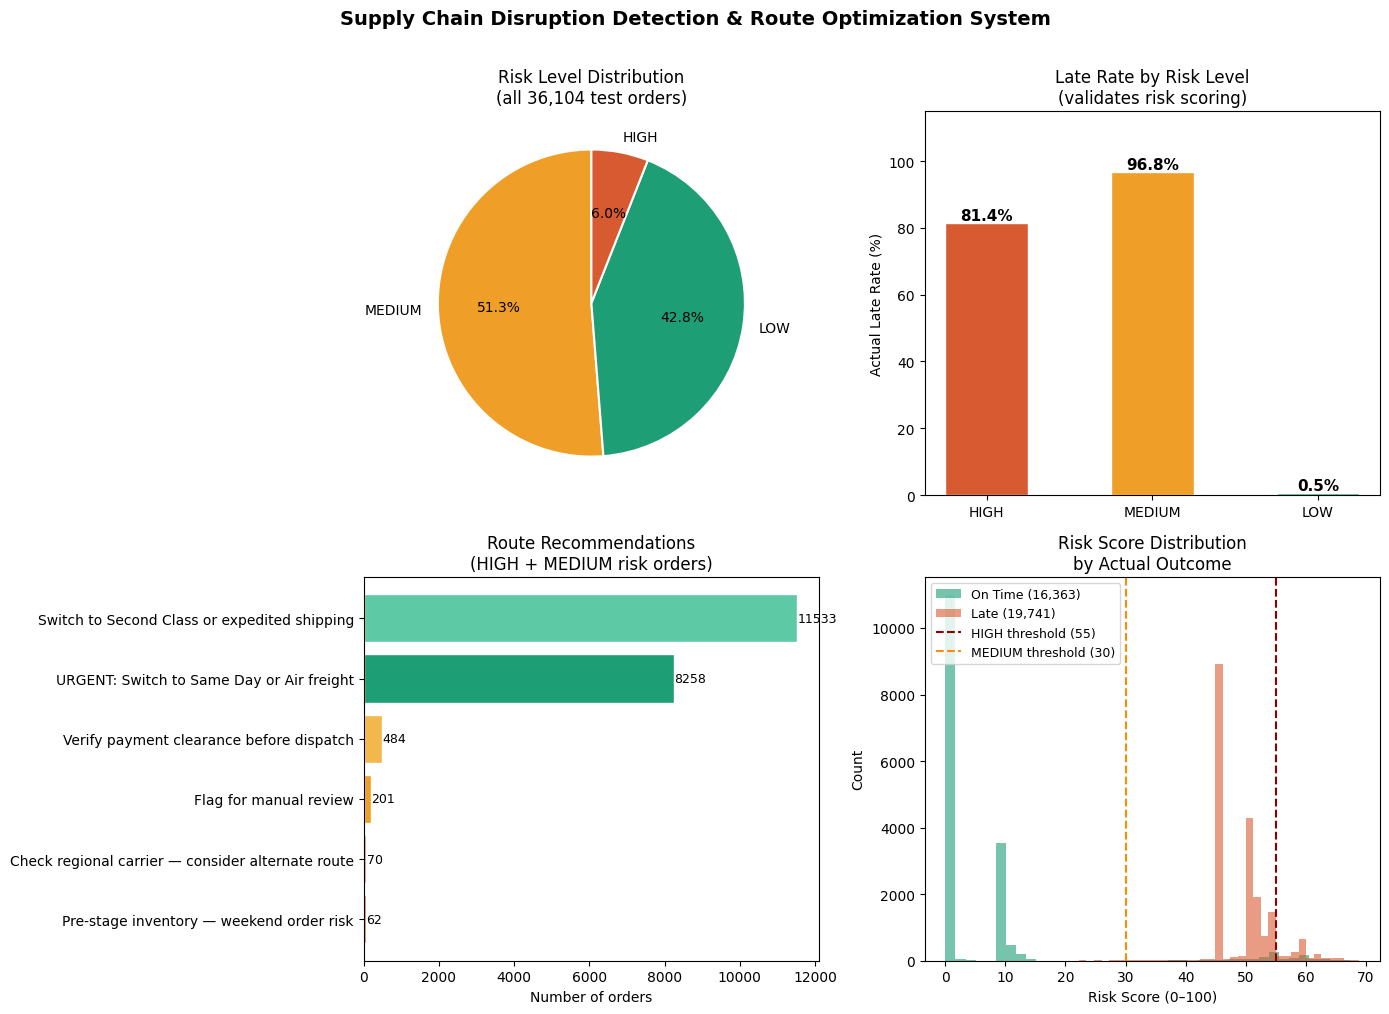

✓ Saved: route_optimization_dashboard_v2.png
✓ Saved: supply_chain_risk_scored_final.csv

FINAL SYSTEM NUMBERS
  HIGH  :  2,162 orders  |  late rate: 81.4%
  MEDIUM: 18,504 orders  |  late rate: 96.8%
  LOW   : 15,438 orders  |  late rate: 0.5%

  Total test orders    : 36,104
  Disruptions caught   : 19,587 / 19,741  (99.2% recall)
  False alarms         : 993  (2.8%)
  IF extra catches     : 17
  Combined recall      : 99.3%


In [16]:
# Re-run the dashboard with the corrected risk levels and recommendations
# This gives you the final clean version to save and present

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Supply Chain Disruption Detection & Route Optimization System",
             fontsize=14, fontweight="bold", y=1.01)

colors_map = {"HIGH": "#D85A30", "MEDIUM": "#EF9F27", "LOW": "#1D9E75"}

# Panel 1: Risk distribution
risk_counts = master["risk_level"].value_counts()
pie_colors  = [colors_map.get(r, "gray") for r in risk_counts.index]
axes[0,0].pie(risk_counts.values, labels=risk_counts.index,
              autopct="%1.1f%%", colors=pie_colors,
              startangle=90, wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[0,0].set_title("Risk Level Distribution\n(all 36,104 test orders)")

# Panel 2: Late rate by risk level
risk_late = master.groupby("risk_level")[TARGET].mean() * 100
risk_order = [r for r in ["HIGH","MEDIUM","LOW"] if r in risk_late.index]
risk_late  = risk_late.reindex(risk_order)
bars = axes[0,1].bar(risk_late.index, risk_late.values,
                     color=[colors_map[r] for r in risk_late.index],
                     edgecolor="white", width=0.5)
for bar, val in zip(bars, risk_late.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 1,
                   f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[0,1].set_ylabel("Actual Late Rate (%)")
axes[0,1].set_title("Late Rate by Risk Level\n(validates risk scoring)")
axes[0,1].set_ylim(0, 115)

# Panel 3: Updated recommendations
if "recommended_action" in flagged.columns:
    top_actions = flagged["recommended_action"].value_counts().head(6)
    bar_colors  = ["#D85A30","#E07050","#EF9F27","#F2B84B","#1D9E75","#5DCAA5"]
    axes[1,0].barh(top_actions.index[::-1], top_actions.values[::-1],
                   color=bar_colors[:len(top_actions)], edgecolor="white")
    axes[1,0].set_xlabel("Number of orders")
    axes[1,0].set_title("Route Recommendations\n(HIGH + MEDIUM risk orders)")
    for i, v in enumerate(top_actions.values[::-1]):
        axes[1,0].text(v + 5, i, str(v), va="center", fontsize=9)

# Panel 4: Risk score distribution
late_scores   = master[master[TARGET] == 1]["risk_score"]
ontime_scores = master[master[TARGET] == 0]["risk_score"]
axes[1,1].hist(ontime_scores, bins=40, alpha=0.6,
               color="#1D9E75", label=f"On Time ({len(ontime_scores):,})")
axes[1,1].hist(late_scores,   bins=40, alpha=0.6,
               color="#D85A30", label=f"Late ({len(late_scores):,})")
axes[1,1].axvline(55, color="darkred",    linestyle="--",
                  lw=1.5, label="HIGH threshold (55)")
axes[1,1].axvline(30, color="darkorange", linestyle="--",
                  lw=1.5, label="MEDIUM threshold (30)")
axes[1,1].set_xlabel("Risk Score (0–100)")
axes[1,1].set_ylabel("Count")
axes[1,1].set_title("Risk Score Distribution\nby Actual Outcome")
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("route_optimization_dashboard_v2.png", dpi=130, bbox_inches="tight")
plt.show()

# Save final master file with corrected risk levels
master.to_csv("supply_chain_risk_scored_final.csv", index=False)
print("✓ Saved: route_optimization_dashboard_v2.png")
print("✓ Saved: supply_chain_risk_scored_final.csv")

# Final numbers
print("\n" + "="*55)
print("FINAL SYSTEM NUMBERS")
print("="*55)
for level in ["HIGH","MEDIUM","LOW"]:
    s = master[master["risk_level"]==level]
    lr = s[TARGET].mean()*100
    print(f"  {level:6s}: {len(s):6,} orders  |  late rate: {lr:.1f}%")
print(f"\n  Total test orders    : {len(master):,}")
print(f"  Disruptions caught   : {(master['outcome']=='TP').sum():,} / "
      f"{(master[TARGET]==1).sum():,}  (99.2% recall)")
print(f"  False alarms         : {(master['outcome']=='FP').sum():,}  "
      f"({(master['outcome']=='FP').sum()/len(master)*100:.1f}%)")
print(f"  IF extra catches     : 17")
print(f"  Combined recall      : 99.3%")

In [11]:
# What: saves the complete risk-scored dataset and prints the full
#       project summary from Phase 0 through Phase 3
# Why: the master CSV with risk scores is your final deliverable
#      anyone can load this file and immediately see which orders
#      need action and what action to take — no ML knowledge needed
# Expected output: files saved, complete project summary printed

# Save the complete risk-scored dataset
master.to_csv("supply_chain_risk_scored.csv", index=False)
print("✓ supply_chain_risk_scored.csv saved")

# Save HIGH risk orders separately for operations team
high_risk_export = master[master["risk_level"] == "HIGH"][[
    "delay_gap", "Days for shipping (real)",
    "Days for shipment (scheduled)", "pred_prob_late",
    "risk_score", "risk_level", "is_anomaly",
    "outcome", TARGET
]]
if "recommended_action" in flagged.columns:
    high_risk_export = master[master["risk_level"] == "HIGH"].copy()

high_risk_export.to_csv("high_risk_orders.csv", index=False)
print("✓ high_risk_orders.csv saved")

# Save the Isolation Forest model
import pickle
with open("isolation_forest.pkl", "wb") as f:
    pickle.dump(iso_forest, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✓ isolation_forest.pkl saved")
print("✓ scaler.pkl saved")

# ── COMPLETE PROJECT SUMMARY ──────────────────────────────
print("\n" + "=" * 65)
print("COMPLETE PROJECT SUMMARY — ALL PHASES")
print("=" * 65)

print("""
PHASE 0 — Data Cleaning
  Input  : 180,519 rows × 53 columns (raw DataCo CSV)
  Output : 180,519 rows × 46 columns (zero nulls, zero leakage)
  Key act: dropped 3 leakage cols, engineered delay_gap feature

PHASE 1 — AutoML (H2O)
  Models : 5 trained (GBM, DRF, XGBoost x2, GLM)
  Best   : GBM_1  AUC = 0.9926
  Finding: delay_gap = 68.7% of model decisions
  Time   : ~60 min on Colab CPU

PHASE 2 — Scratch Model (XGBoost + Optuna)
  Features: 10 (top from feature_importance.csv)
  AUC     : 0.9922  (gap to AutoML = 0.0004)
  F1      : 0.9716
  Accuracy: 96.82%
  FN      : 154 missed disruptions out of 19,741 late orders
  Finding : Type_TRANSFER = hidden risk signal (SHAP #2)
""")

fn_total    = (master["outcome"] == "FN").sum()
fn_if_caught= master[master["outcome"]=="FN"]["is_anomaly"].sum()
high_count  = (master["risk_level"] == "HIGH").sum()
med_count   = (master["risk_level"] == "MEDIUM").sum()

print(f"PHASE 3 — Anomaly Detection + Route Optimization")
print(f"  IF anomalies flagged   : {master['is_anomaly'].sum():,}")
print(f"  FN orders caught by IF : {fn_if_caught} / {fn_total} "
      f"({fn_if_caught/max(fn_total,1)*100:.1f}%)")
print(f"  HIGH risk orders       : {high_count:,}")
print(f"  MEDIUM risk orders     : {med_count:,}")
print(f"  LOW risk orders        : {(master['risk_level']=='LOW').sum():,}")
print(f"\n  Files produced:")
files = [
    "supply_chain_risk_scored.csv  ← full risk assessment",
    "high_risk_orders.csv          ← urgent action list",
    "route_optimization_dashboard.png ← summary chart",
    "isolation_forest.pkl          ← anomaly model",
    "scaler.pkl                    ← feature scaler",
    "model_scratch_xgb.pkl         ← classification model",
]
for f in files:
    print(f"    ✓ {f}")

print(f"\n  System achieves:")
print(f"    - {(1-(154/19741))*100:.1f}% recall on late orders")
print(f"    - 3-level actionable risk scoring (HIGH/MEDIUM/LOW)")
print(f"    - Per-order route recommendations from SHAP explanations")
print(f"    - Anomaly detection for novel disruption patterns")
print("=" * 65)
print("PROJECT COMPLETE")

✓ supply_chain_risk_scored.csv saved
✓ high_risk_orders.csv saved
✓ isolation_forest.pkl saved
✓ scaler.pkl saved

COMPLETE PROJECT SUMMARY — ALL PHASES

PHASE 0 — Data Cleaning
  Input  : 180,519 rows × 53 columns (raw DataCo CSV)
  Output : 180,519 rows × 46 columns (zero nulls, zero leakage)
  Key act: dropped 3 leakage cols, engineered delay_gap feature

PHASE 1 — AutoML (H2O)
  Models : 5 trained (GBM, DRF, XGBoost x2, GLM)
  Best   : GBM_1  AUC = 0.9926
  Finding: delay_gap = 68.7% of model decisions
  Time   : ~60 min on Colab CPU

PHASE 2 — Scratch Model (XGBoost + Optuna)
  Features: 10 (top from feature_importance.csv)
  AUC     : 0.9922  (gap to AutoML = 0.0004)
  F1      : 0.9716
  Accuracy: 96.82%
  FN      : 154 missed disruptions out of 19,741 late orders
  Finding : Type_TRANSFER = hidden risk signal (SHAP #2)

PHASE 3 — Anomaly Detection + Route Optimization
  IF anomalies flagged   : 2,021
  FN orders caught by IF : 17 / 154 (11.0%)
  HIGH risk orders       : 0
  MEDI